In [42]:
import pandas as pd
import xgboost as xgb
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [43]:
bookings = pd.read_csv('hotel_bookings.csv')
bookings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  object 
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [44]:
bookings.describe()

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [45]:
bookings['is_canceled'] = bookings['is_canceled'].map({'yes': 1, 'no': 0})


<Axes: xlabel='is_canceled'>

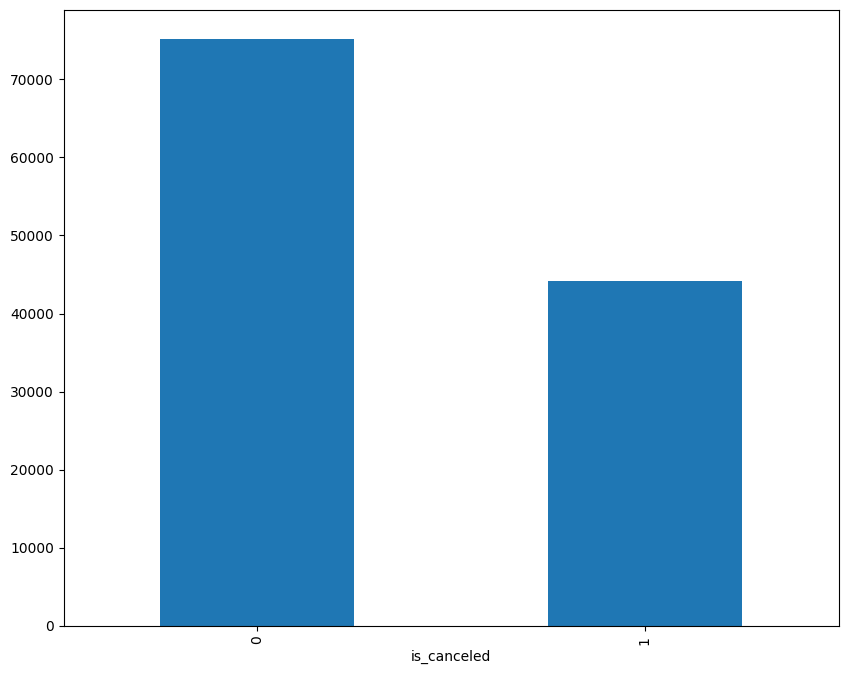

In [46]:
bookings['is_canceled'].value_counts().plot(kind='bar')

In [47]:
bookings['is_canceled'].value_counts()/bookings['is_canceled'].count()*100

is_canceled
0    62.958372
1    37.041628
Name: count, dtype: float64

In [48]:
bookings1 = bookings.corr(numeric_only=True)

In [49]:
bookings1.corr()['lead_time'].sort_values(ascending=False)

lead_time                         1.000000
is_canceled                       0.525633
days_in_waiting_list              0.283166
stays_in_week_nights              0.202346
company                           0.187654
adults                            0.160673
arrival_date_week_number          0.144556
stays_in_weekend_nights           0.090773
previous_cancellations            0.082003
arrival_date_year                -0.063031
arrival_date_day_of_month        -0.078734
booking_changes                  -0.147523
babies                           -0.161362
adr                              -0.203618
children                         -0.214319
agent                            -0.241128
previous_bookings_not_canceled   -0.300588
is_repeated_guest                -0.358297
total_of_special_requests        -0.363541
required_car_parking_spaces      -0.406086
Name: lead_time, dtype: float64

In [ ]:
y = bookings['is_canceled']
X = bookings.drop(columns=['is_canceled'])

In [51]:
# --- Convert categorical columns to numeric ---
X = pd.get_dummies(X, drop_first=True)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=123)
xgb_clf = xgb.XGBClassifier(random_state=123, n_estimators=10)
xgb_clf.get_params()

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 10,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 123,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [53]:
xgb_clf.fit(X_train, y_train)

# --- Predict ---
preds = xgb_clf.predict(X_test)

# --- Accuracy ---
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 1.0


In [54]:
accuracy = float(np.sum(preds==y_test)) // y_test.shape[0]
print("Baseline accuracy:" , accuracy)

Baseline accuracy: 1.0


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

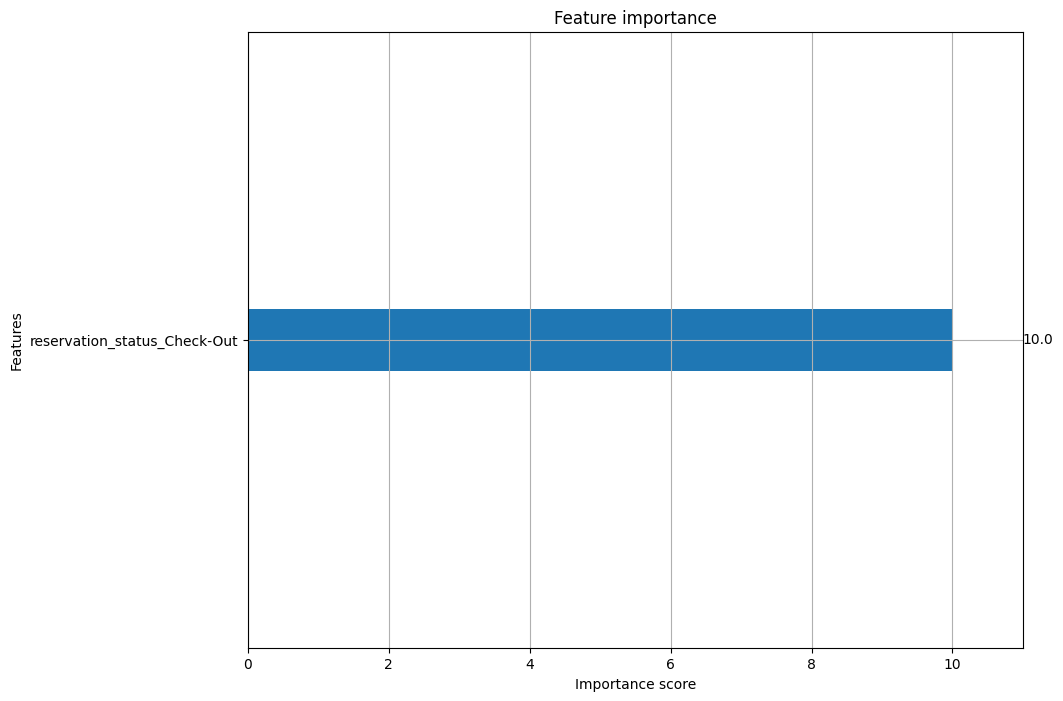

In [55]:
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10.0, 8)
xgb.plot_importance(xgb_clf)

In [56]:
X = bookings.drop("is_canceled", axis=1)


In [57]:
X = pd.get_dummies(X, drop_first=True)


In [58]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    random_state=123,
    n_estimators=200,
    learning_rate=0.1
)

xgb_clf.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

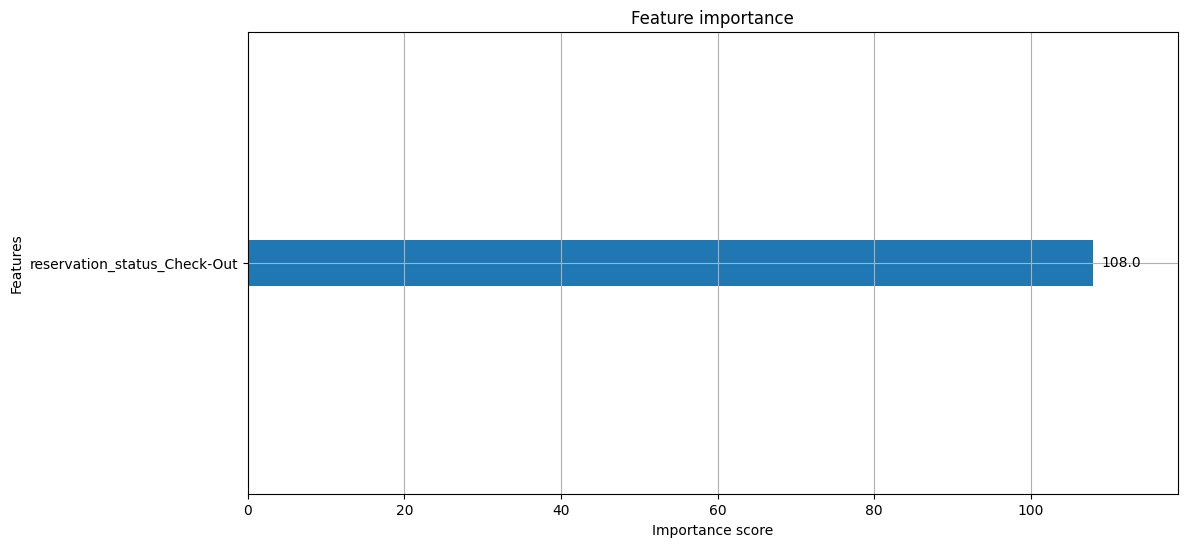

In [59]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12,6)
xgb.plot_importance(xgb_clf)
plt.show()


In [63]:
print(y.value_counts(dropna=False))
print(len(y))


Series([], Name: count, dtype: int64)
0


In [64]:
print(bookings['is_canceled'].unique())


[0 1]
